# 신한카드 요식업종 가맹점 거래 안정성 분석
2023.01 ~ 2024.12 서울 성동구 영세/중소 가맹점 데이터

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [3]:
total = pd.read_csv("D:\SSAFY\GamjaNeverDie\merged_df.csv", encoding = "utf-8")

In [4]:
col = total.columns
print(col)

Index(['가맹점구분번호', '가맹점주소', '가맹점명', '브랜드구분코드', '가맹점지역', '업종', '상권', '개설일',
       '폐업일', '기준년월', '가맹점 운영개월수 구간', '매출금액 구간', '매출건수 구간', '유니크 고객 수 구간',
       '객단가 구간', '취소율 구간', '배달매출금액 비율', '동일 업종 매출금액 비율', '동일 업종 매출건수 비율',
       '동일 업종 내 매출 순위 비율', '동일 상권 내 매출 순위 비율', '동일 업종 내 해지 가맹점 비중',
       '동일 상권 내 해지 가맹점 비중', '기준년월.1', '남성 20대이하 고객 비중', '남성 30대 고객 비중',
       '남성 40대 고객 비중', '남성 50대 고객 비중', '남성 60대이상 고객 비중', '여성 20대이하 고객 비중',
       '여성 30대 고객 비중', '여성 40대 고객 비중', '여성 50대 고객 비중', '여성 60대이상 고객 비중',
       '재방문 고객 비중', '신규 고객 비중', '거주 이용 고객 비율', '직장 이용 고객 비율', '유동인구 이용 고객 비율'],
      dtype='object')


## 분석 계획

1. 취소율 급증 예측 모델

종속변수 : 취소율 급증 여부 (0or1)

독립변수 : 배달매출금액 비율, 동일 업종 매출금액 비율 (업종 내 경쟁도 비교), 신규 고객 비중, 재방문 고객 비중, 치소율 전월 대비 변화율, 매출 건수 변화율, 객단가 변화율



가설 : 배달 비율이 높고 신규 고객이 급감한 매장은 취소율 급증 가능성이 높다.





2. 매출 변동성 예측 모델

종속변수 : 최근 3개월 간 매출 표준편차 상위 20% 인지에 대한 여부

독립변수  : 매출금액 증감률, 매출건수 증감률, 상권 내 매출 순위 비율, 동일 업종 내 해지 가맹점 비중, 고객 분포 다양성 지수 (특정 고객층이 집중된다면 하이리스크임)

가설 : 고객층이 편중되고 업종 내 해지 비중이 높은 지역일수록 매출 변동성이 커진다.



## 데이터 기본 정제

In [5]:
print(total.shape)

(1960290, 39)


In [7]:
print(f"\n가맹점 수: {total['가맹점구분번호'].nunique()}")
print(f"기간: {total['기준년월'].min()} ~ {total['기준년월'].max()}")


가맹점 수: 4185
기간: 202301 ~ 202412


In [8]:
# 결측치를 나타내는 특수값(-999999.9, 999999.9) 처리
special_values = [-999999.9, 999999.9]
for col in total.select_dtypes(include=[np.number]).columns:
    total.loc[total[col].isin(special_values), col] = np.nan

In [9]:
# 날짜 형식 변환
total['기준년월'] = pd.to_datetime(total['기준년월'], format='%Y%m', errors='coerce')
total['개설일'] = pd.to_datetime(total['개설일'], format='%Y%m%d', errors='coerce')
total['폐업일'] = pd.to_datetime(total['폐업일'], format='%Y%m%d', errors='coerce')

In [10]:
# 개설일 ~기준년월 기간 필터링 (개설일 이후 데이터만 활용)
df = total[total['기준년월'] >= total['개설일']].copy()

In [11]:
# 폐업일 이전 데이터만 (폐업일이 있는 경우)
df = df[(df['폐업일'].isna()) | (df['기준년월'] <= df['폐업일'])].copy()

In [12]:
print(f"\n정제 후 데이터 shape: {df.shape}")
print(f"\n데이터 샘플:\n{df.head()}")


정제 후 데이터 shape: (1946312, 39)

데이터 샘플:
      가맹점구분번호                가맹점주소  가맹점명 브랜드구분코드   가맹점지역          업종  상권  \
0  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**     NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
1  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**     NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
2  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**     NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
3  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**     NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   
4  000F03E44A  서울특별시 성동구 왕십리로4가길 9  육육**     NaN  서울 성동구  중식-딤섬/중식만두  뚝섬   

         개설일 폐업일       기준년월  ... 여성 20대이하 고객 비중 여성 30대 고객 비중 여성 40대 고객 비중  \
0 2022-02-25 NaT 2024-04-01  ...         0.0000       14.400       0.0000   
1 2022-02-25 NaT 2024-04-01  ...         0.0000       14.000       0.0000   
2 2022-02-25 NaT 2024-04-01  ...         4.1917       12.550       0.0000   
3 2022-02-25 NaT 2024-04-01  ...        13.3750        8.346       6.6875   
4 2022-02-25 NaT 2024-04-01  ...         0.0000       14.400       0.0000   

  여성 50대 고객 비중 여성 60대이상 고객 비중 재방문 고객 비중 

## 파생변수 만들기
- 매출금액 변화율
- 매출건수 변화율
- 객단가 변화율
- 취소율 증감
- 매출 표준편차 (3개월)
- 매출 표준편차 (6개월)
- 매출 안정지수
- 고객 다양성 지수

구간값을 양적변수로 변환 - 숫자로 변환
-> 반복작업이므로 함수로 구현 (엔지니어링)

In [13]:
# 구간값을 숫자로 변환하는 함수
def interval_to_numeric(interval_str):
    """구간 문자열을 대표값으로 변환 (0에 가까울수록 상위)"""
    if pd.isna(interval_str):
        return np.nan
    mapping = {
        '10%이하': 5,
        '10-25%': 17.5,
        '25-50%': 37.5,
        '50-75%': 62.5,
        '75-90%': 82.5,
        '90%초과': 95
    }
    return mapping.get(interval_str, np.nan)

In [14]:
df['매출금액_수치'] = df['매출금액 구간'].apply(interval_to_numeric)
df['매출건수_수치'] = df['매출건수 구간'].apply(interval_to_numeric)
df['고객수_수치'] = df['유니크 고객 수 구간'].apply(interval_to_numeric)
df['객단가_수치'] = df['객단가 구간'].apply(interval_to_numeric)

In [15]:
# 취소율 구간 변환 (1~6 구간, 1이 낮음 = 좋음)
df['취소율_수치'] = pd.to_numeric(df['취소율 구간'], errors='coerce')

In [16]:
# 가맹점별 시계열 정렬
df = df.sort_values(['가맹점구분번호', '기준년월']).reset_index(drop=True)

### 전월 대비 변화율 계산

In [17]:
for col_orig, col_new in [('매출금액_수치', '매출금액_변화율'), 
                          ('매출건수_수치', '매출건수_변화율'),
                          ('객단가_수치', '객단가_변화율')]:
    df[col_new] = df.groupby('가맹점구분번호')[col_orig].pct_change()


### 취소율 증감

In [18]:
df['취소율_증감'] = df.groupby('가맹점구분번호')['취소율_수치'].diff()

### 매출 표준편차

In [22]:
df['매출_표준편차_6개월'] = df.groupby('가맹점구분번호')['매출금액_수치'].transform(
    lambda x: x.rolling(window=6, min_periods=3).std()
)
df['매출_표준편차_3개월'] = df.groupby('가맹점구분번호')['매출금액_수치'].transform(
    lambda x: x.rolling(window=3, min_periods=2).std()
)

### 매출 안정성 지수 (평균/표준편차, 높을수록 안정적)

In [23]:
df['매출_평균_6개월'] = df.groupby('가맹점구분번호')['매출금액_수치'].transform(
    lambda x: x.rolling(window=6, min_periods=3).mean()
)
df['매출_안정성지수'] = df['매출_평균_6개월'] / (df['매출_표준편차_6개월'] + 1e-5)

### 고객 다양성 분포 지수

In [24]:
gender_age_cols = [
    '남성 20대이하 고객 비중', '남성 30대 고객 비중', '남성 40대 고객 비중', 
    '남성 50대 고객 비중', '남성 60대이상 고객 비중',
    '여성 20대이하 고객 비중', '여성 30대 고객 비중', '여성 40대 고객 비중',
    '여성 50대 고객 비중', '여성 60대이상 고객 비중'
]

def calculate_diversity(row):
    """고객층 다양성 지수 계산 (Shannon Entropy)"""
    values = row[gender_age_cols].values
    values = values[~np.isnan(values)]
    if len(values) == 0 or values.sum() == 0:
        return np.nan
    probs = values / values.sum()
    probs = probs[probs > 0]
    return -np.sum(probs * np.log(probs))

df['고객_다양성지수'] = df.apply(calculate_diversity, axis=1)

TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

## 종속변수 정의
취소율 급증 여부

In [26]:
# 업종별 취소율 평균 계산
industry_cancel_mean = df.groupby(['업종', '기준년월'])['취소율_수치'].mean()
df['업종_평균취소율'] = df.apply(
    lambda x: industry_cancel_mean.get((x['업종'], x['기준년월']), np.nan), axis=1
)

# 취소율 급증: 업종 평균 대비 1.5배 이상
df['취소율_급증여부'] = (
    (df['취소율_수치'] >= df['업종_평균취소율'] * 1.5) & 
    (df['취소율_수치'].notna())
).astype(int)

In [27]:
# 최근 3개월 매출 표준편차 상위 20%
volatility_threshold = df['매출_표준편차_3개월'].quantile(0.8)
df['매출변동성_급증여부'] = (df['매출_표준편차_3개월'] >= volatility_threshold).astype(int)

print(f"\n목표 변수 정의 완료:")
print(f"취소율 급증 비율: {df['취소율_급증여부'].mean():.2%}")
print(f"매출 변동성 급증 비율: {df['매출변동성_급증여부'].mean():.2%}")


목표 변수 정의 완료:
취소율 급증 비율: 0.00%
매출 변동성 급증 비율: 0.00%


# EDA

In [30]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 윈도우 (Malgun Gothic), 맥 (AppleGothic), 리눅스(나눔고딕) 등 환경에 맞는 폰트 지정
plt.rc('font', family='Malgun Gothic')   # Windows: 맑은 고딕
# plt.rc('font', family='AppleGothic')   # macOS
# plt.rc('font', family='NanumGothic')   # Linux (나눔고딕 설치 필요)

# 마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

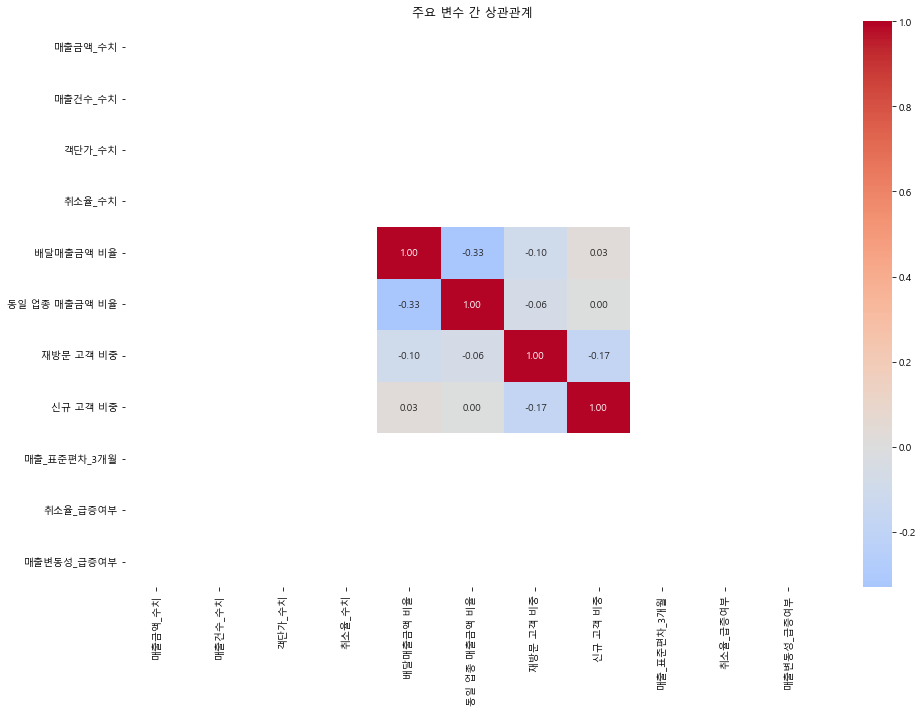

In [31]:
correlation_features = [
    '매출금액_수치', '매출건수_수치', '객단가_수치',
    '취소율_수치', '배달매출금액 비율', '동일 업종 매출금액 비율',
    '재방문 고객 비중', '신규 고객 비중', 
    '매출_표준편차_3개월',  '취소율_급증여부', '매출변동성_급증여부'
]
plt.figure(figsize=(14, 10))
corr_matrix = df[correlation_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('주요 변수 간 상관관계')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

ValueError: not enough values to unpack (expected 2, got 0)

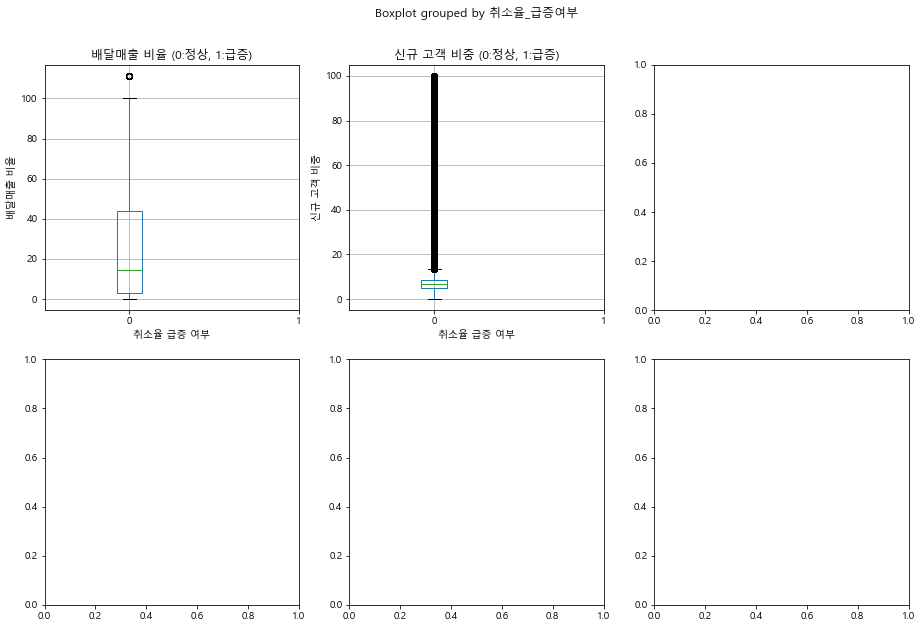

In [32]:
# 취소율 급증 vs 정상 점포 비교
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

compare_features = [
    ('배달매출금액 비율', '배달매출 비율'),
    ('신규 고객 비중', '신규 고객 비중'),
    ('매출금액_수치', '매출금액'),
    ('동일 업종 매출금액 비율', '업종 대비 매출 비율'),
    ('매출_표준편차_3개월', '매출 변동성(3개월)'),
    
]

for idx, (feature, title) in enumerate(compare_features):
    ax = axes[idx // 3, idx % 3]
    df_plot = df[df[feature].notna()]
    df_plot.boxplot(column=feature, by='취소율_급증여부', ax=ax)
    ax.set_title(f'{title} (0:정상, 1:급증)')
    ax.set_xlabel('취소율 급증 여부')
    ax.set_ylabel(title)
    plt.sca(ax)
    plt.xticks([1, 2], ['0', '1'])

plt.tight_layout()
plt.savefig('cancel_surge_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


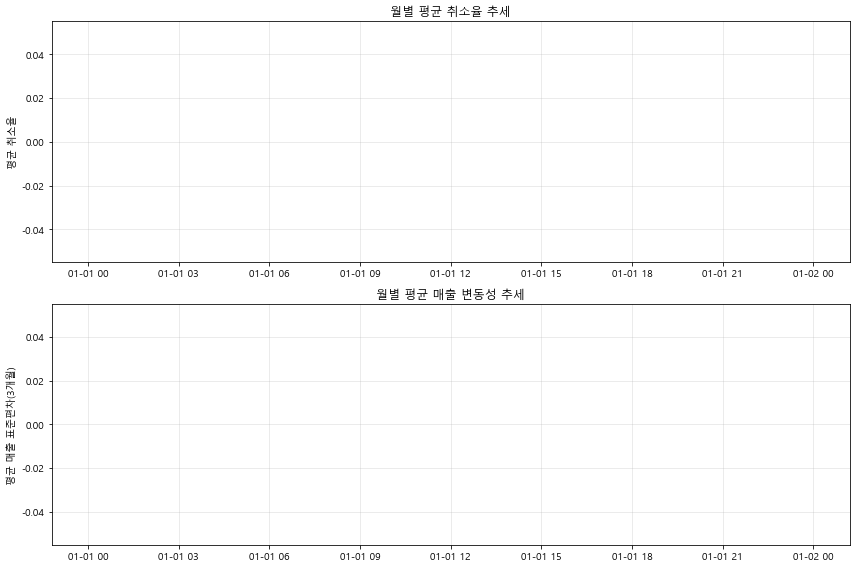

In [33]:
# 5-3. 시계열 추세 분석
monthly_stats = df.groupby('기준년월').agg({
    '취소율_수치': 'mean',
    '취소율_급증여부': 'mean',
    '매출_표준편차_3개월': 'mean',
    '매출변동성_급증여부': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(monthly_stats['기준년월'], monthly_stats['취소율_수치'], marker='o')
axes[0].set_title('월별 평균 취소율 추세')
axes[0].set_ylabel('평균 취소율')
axes[0].grid(True, alpha=0.3)

axes[1].plot(monthly_stats['기준년월'], monthly_stats['매출_표준편차_3개월'], marker='s', color='orange')
axes[1].set_title('월별 평균 매출 변동성 추세')
axes[1].set_ylabel('평균 매출 표준편차(3개월)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_series_trends.png', dpi=300, bbox_inches='tight')
plt.show()

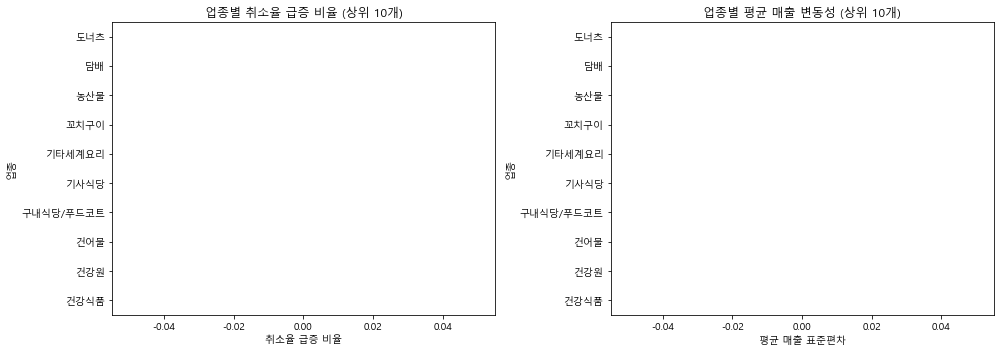

In [34]:
# 5-4. 업종별 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 업종별 취소율 급증 비율
industry_cancel = df.groupby('업종')['취소율_급증여부'].mean().sort_values(ascending=False).head(10)
industry_cancel.plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('업종별 취소율 급증 비율 (상위 10개)')
axes[0].set_xlabel('취소율 급증 비율')

# 업종별 매출 변동성
industry_vol = df.groupby('업종')['매출_표준편차_3개월'].mean().sort_values(ascending=False).head(10)
industry_vol.plot(kind='barh', ax=axes[1], color='skyblue')
axes[1].set_title('업종별 평균 매출 변동성 (상위 10개)')
axes[1].set_xlabel('평균 매출 표준편차')

plt.tight_layout()
plt.savefig('industry_analysis.png', dpi=300, bbox_inches='tight')
plt.show()